# 02 — BRT Diagnostics (Step 3 verification)

Visually confirms that the **uncontrolled backward-reachable tube** in
`reachability/hopf.py` is correct, beyond the 26 passing unit tests.

These are **diagnostic** figures (to catch bugs), *not* paper figures — the
headline Pc(t) curve comes later in Step 5. This notebook **imports** the
library functions; it never re-derives `value()` inline, so a bug in `hopf.py`
must surface here rather than being masked by parallel notebook code.

Three figures:
1. BRT boundary in the dr–dt plane at several times (geometry + time direction)
2. BRT membership heatmap (sign convention + velocity-dependence)
3. `value(x(t), t)` along trajectories (bridge to trusted separation distance)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from spacecraft_brt.dynamics.hcw import (
    hcw_state_transition,
    propagate_hcw,
    separation_distance,
    time_of_closest_approach,
)
from spacecraft_brt.dynamics.scenario import make_crossing_conjunction
from spacecraft_brt.reachability.hopf import value, brt_boundary_points
from spacecraft_brt.reachability.target_set import signed_distance
from spacecraft_brt.utils.constants import R_HBR_DEFAULT, PC_THRESHOLD

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
RNG = np.random.default_rng(0)


def value_along_trajectory(states, t_eval, T, n, hard_body_r):
    """Evaluate V(x(t), t) where EACH state is taken at ITS OWN time.

    value() computes a single Phi(T - t) and vectorizes over states at one
    fixed t; it does not accept a vector of times. Here every timestep has a
    different t, so we loop -- one cheap value() call per step.
    """
    return np.array([
        float(value(states[i], t=t_eval[i], T=T, n=n, hard_body_r=hard_body_r))
        for i in range(len(t_eval))
    ])

## Setup — scenario, horizon, hard-body radius

In [2]:
# Realistic LEO crossing conjunction (1 km nominal miss). T = encounter horizon.
scenario = make_crossing_conjunction(altitude_km=550.0, miss_distance=1.0,
                                     relative_velocity_mps=7000.0)
n = scenario.n                 # mean motion (rad/s)
T = scenario.t_horizon         # BRT final time (s) -- value() propagates over (T - t)
R_hbr = scenario.hard_body_r   # combined hard-body radius (m)
print(scenario.summary())
print(f"n = {n:.6e} rad/s | T = {T:.1f} s ({T/3600:.2f} hr) | R_hbr = {R_hbr:.1f} m")

# Geometry figures (1 & 2) use a SHORTER horizon so the BRT shape is readable.
# Over the full ~24 hr T the pullback winds for ~15 orbits and the boundary
# stretches into an unreadable along-track streak. The short horizon shows the
# shear/growth clearly; Fig 3 still uses the real scenario T.
period = 2 * np.pi / n
T_geom = period / 2          # ~47 min: half an orbit, enough to show the shear
print(f"orbital period = {period/60:.1f} min | T_geom (figs 1-2) = {T_geom/60:.1f} min")

Scenario: LEO 550km crossing-conjunction
  SMA:          6921.0 km
  Mean motion:  1.0965 mrad/s
  T horizon:    23.88 hr
  TCA:          23.876 hr (85951.9 s)
  Miss distance:1000.0 m
  Hard-body R:  10.0 m
  x0:           [1.00000000e+03 5.65486678e+05 1.12120583e-07 2.85023015e-13
 1.48763994e-12 7.00000000e+03]

n = 1.096518e-03 rad/s | T = 85951.9 s (23.88 hr) | R_hbr = 10.0 m
orbital period = 95.5 min | T_geom (figs 1-2) = 47.8 min


## Figure 1 — BRT boundary in the dr–dt plane at several times

**What correct looks like:**
- At **t = T** the boundary is *exactly* the collision-sphere circle (radius
  `R_hbr`). If not, the time-direction/sign is broken.
- Going **backward** in time over a sub-orbit window the boundary **grows and
  shears/elongates** (HCW stretches it, mainly along-track). It must not stay a
  circle. (We use a short horizon here so the shape is readable; over a full
  24 hr the boundary winds for ~15 orbits into an unreadable streak.)

**Failure modes:**
- Boundaries *shrink* backward in time → time direction flipped.
- Boundaries grow but stay perfectly circular → dynamics not applied.
- Boundary doesn't contain the sphere at t < T → sign issue.


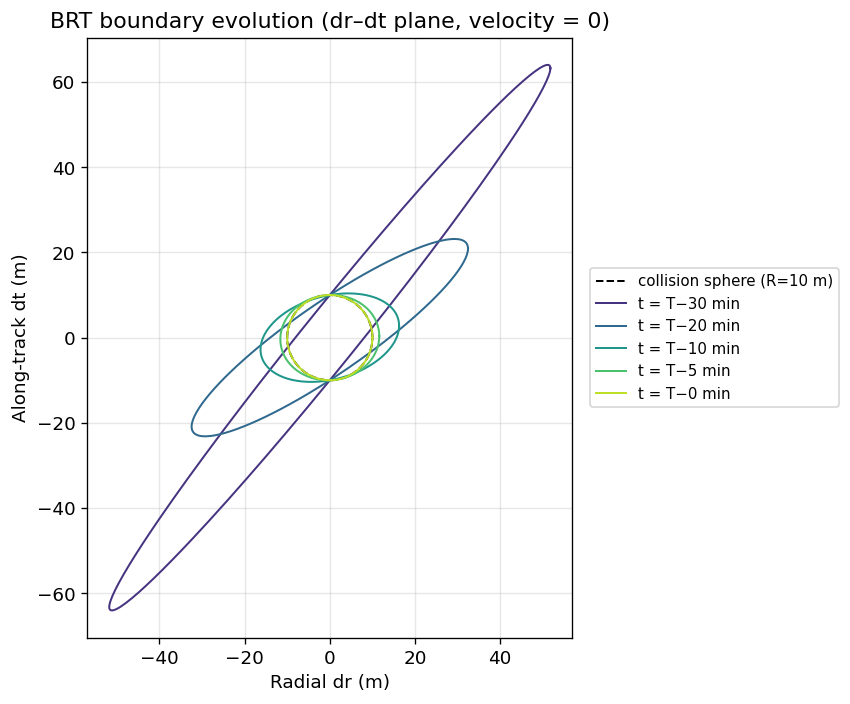

In [3]:
# Sub-orbit deltas (T_geom - t), in minutes, so the shape stays readable.
minute = 60.0
deltas = [0.0, 5*minute, 10*minute, 20*minute, 30*minute]   # T_geom - t
times = sorted({max(T_geom - d, 0.0) for d in deltas})
colors = cm.viridis(np.linspace(0.15, 0.9, len(times)))

fig, ax = plt.subplots(figsize=(7, 6))

# Collision sphere (target set) outline
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(R_hbr*np.cos(theta), R_hbr*np.sin(theta), 'k--', lw=1.2,
        label=f'collision sphere (R={R_hbr:.0f} m)')

for c, t in zip(colors, times):
    pts = brt_boundary_points(t, T_geom, n, hard_body_r=R_hbr, n_samples=200,
                              velocity=np.zeros(3))
    closed = np.vstack([pts[:, :2], pts[0, :2]])
    ax.plot(closed[:, 0], closed[:, 1], color=c, lw=1.2,
            label=f't = T−{(T_geom - t)/60:.0f} min')

ax.set_xlabel('Radial dr (m)')
ax.set_ylabel('Along-track dt (m)')
ax.set_title('BRT boundary evolution (dr–dt plane, velocity = 0)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig('../figures/02_brt_boundary_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

## Figure 2 — BRT membership heatmap (sign + velocity-dependence)

For each grid point in the dr–dt plane we build the full 6D state and evaluate
`value(X, t=0, T, n, R_hbr)`. **Panel A** uses zero velocity; **Panel B** adds a
closing velocity.

**What correct looks like:**
- The **unsafe** region (V < 0) **contains** the sphere and bulges toward where
  states drift *from*.
- Panel B's unsafe region is **shifted** vs Panel A — velocity changes which
  positions reach the sphere. Visual proof that velocity matters via the
  dynamics even though l(x) is position-only.

**Failure modes:**
- Colors swapped (sphere sits in the "safe" color) → sign inverted.
- Panels A and B identical → velocity not flowing through value().
- Unsafe region doesn't enclose the sphere → bug.

*Note on axes:* the unsafe region is narrow in radial (dr ≈ ±R_hbr) but sheared
wide along-track (dt). We zoom the dr axis to ±30 m (dt to ±L) so it reads as a
region rather than a thin sliver — so the dr and dt scales differ here (not
equal-aspect), a deliberate legibility choice for this diagnostic.


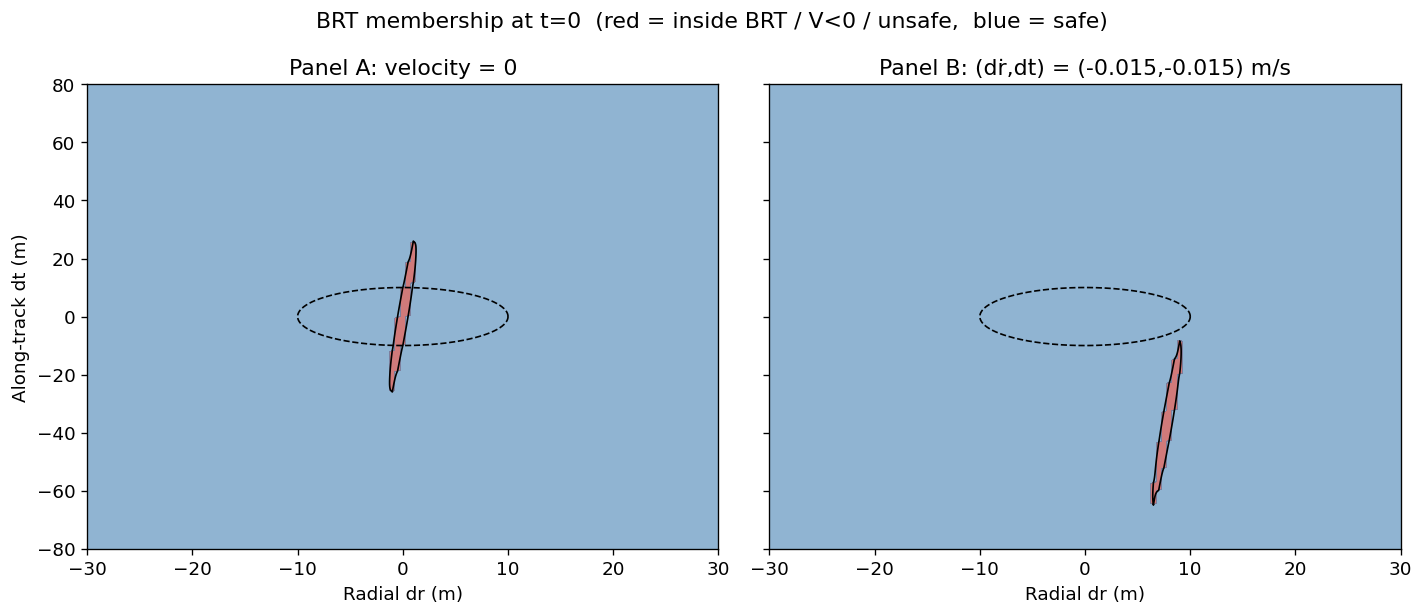

sphere-center sign check: value at origin = -10.0 (should be < 0: origin always reaches itself)
unsafe cells A=169 B=185 | centroid A=(0.0, 0.0) m  B=(7.5, -36.5) m  (B shifted by velocity -> velocity flows through value())


In [4]:
# Over the short geometry horizon the unsafe BRT is only tens of m across, so
# the grid must be matched to that scale (~tens of m) or the blob is sub-pixel.
L = 80.0     # half-width of the grid (m) -- matched to the BRT bulge at T_geom
g = 321
axis = np.linspace(-L, L, g)
DR, DT = np.meshgrid(axis, axis)
flat = np.column_stack([DR.ravel(), DT.ravel(), np.zeros(DR.size)])

def membership(vel):
    X = np.zeros((flat.shape[0], 6))
    X[:, :3] = flat
    X[:, 3:] = vel
    # Use the short geometry horizon so the unsafe region is a readable blob.
    return value(X, t=0.0, T=T_geom, n=n, hard_body_r=R_hbr).reshape(DR.shape)

# In-plane closing velocity (radial+along-track) so Panel B visibly shifts the
# in-plane unsafe region. (Pure cross-track velocity decouples in HCW and would
# barely change the dr-dt picture.)
# Tiny in-plane velocity: over the ~48 min horizon even 0.015 m/s shifts the
# unsafe region by tens of m (velocity dominates position over this time), so
# the two panels are visibly different.
vel_close = np.array([-0.015, -0.015, 0.0])   # m/s, in-plane drift
V0 = membership(np.zeros(3))
V1 = membership(vel_close)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, Vgrid, ttl in zip(axes, [V0, V1],
                          ['Panel A: velocity = 0',
                           f'Panel B: (dṙ,dṫ) = ({vel_close[0]},{vel_close[1]}) m/s']):
    ax.contourf(DR, DT, np.sign(Vgrid),
                levels=[-1.5, 0, 1.5], colors=['firebrick', 'steelblue'], alpha=0.6)
    ax.contour(DR, DT, Vgrid, levels=[0], colors='k', linewidths=1.0)
    ax.plot(R_hbr*np.cos(theta), R_hbr*np.sin(theta), 'k--', lw=1.0)
    ax.set_xlabel('Radial dr (m)')
    ax.set_title(ttl)
    # The unsafe region is narrow in dr but sheared wide in dt. Zoom the dr axis
    # so it reads as a region, not a thin sliver. (No equal aspect -- the dr/dt
    # scales differ here on purpose for legibility.)
    ax.set_xlim(-30, 30)
    ax.set_ylim(-L, L)
axes[0].set_ylabel('Along-track dt (m)')
fig.suptitle('BRT membership at t=0  (red = inside BRT / V<0 / unsafe,  blue = safe)')
plt.tight_layout()
plt.savefig('../figures/02_brt_membership_map.png', dpi=120)
plt.show()

print('sphere-center sign check: value at origin =',
      float(value(np.zeros(6), t=0.0, T=T_geom, n=n, hard_body_r=R_hbr)),
      '(should be < 0: origin always reaches itself)')
def centroid_m(V):
    aw = np.argwhere(V < 0)
    if not len(aw):
        return None
    ci = aw.mean(0)
    return (round(float(axis[int(ci[1])]), 1), round(float(axis[int(ci[0])]), 1))
print(f'unsafe cells A={int((V0<0).sum())} B={int((V1<0).sum())} | '
      f'centroid A={centroid_m(V0)} m  B={centroid_m(V1)} m  '
      f'(B shifted by velocity -> velocity flows through value())')

## Figure 3 — value along a trajectory (bridge to trusted code)

Two curves per trajectory:
- **Curve A** — `V(x(t), t)` = "*will* I be in the sphere by T?"
- **Curve B** — `l(x(t)) = separation − R_hbr` = "am I in the sphere *now*?"

They are **not** expected to coincide except near **t = T**, where Φ→I so V→l.

We show **two versions** to prove the V<0 branch fires in both an artificial and
a physically meaningful case.

**What correct looks like:**
- Near t = T the two curves **converge** (V(x,T)=l(x) exactly).
- For a trajectory that passes through the sphere, Curve A goes negative
  **earlier than / as early as** Curve B (future collision known before present
  collision). If A goes negative *later*, time-direction is suspect.

**Failure mode:** curves identical everywhere → value() isn't propagating.


### Figure 3A — nominal trajectory, artificially close (5 m miss)

⚠️ This is an **artificially close** trajectory (`miss_distance = 5 m`) used
only to exercise the V<0 branch on the *nominal* path. It is **not a realistic
conjunction** — a real 1 km miss never enters a 10 m sphere. Figure 3B uses the
realistic case.


3A nominal miss distance = 5.00 m (R_hbr = 10 m)


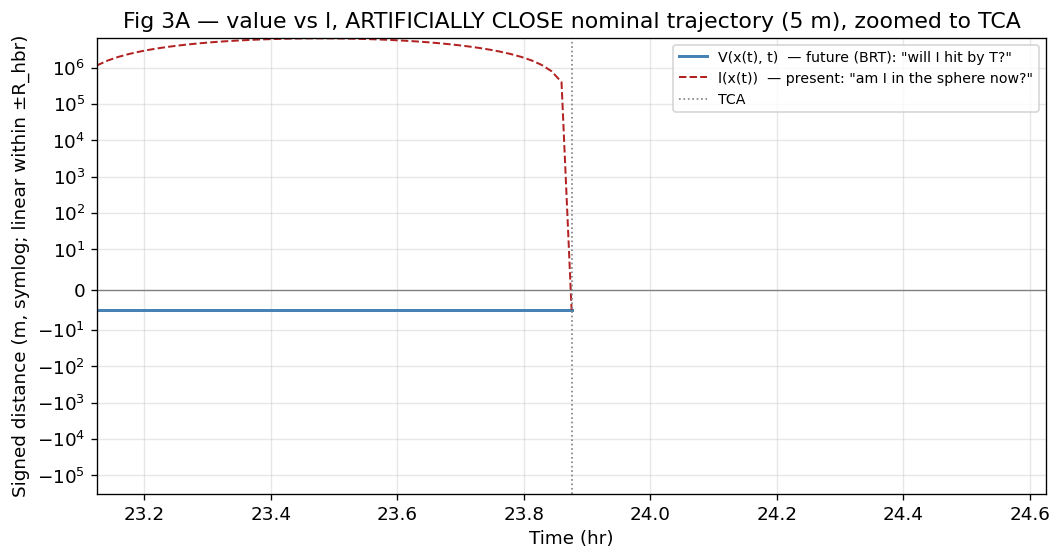

In [5]:
sc_close = make_crossing_conjunction(altitude_km=550.0, miss_distance=0.005,
                                     relative_velocity_mps=7000.0)
T_c = sc_close.t_horizon
t_eval, states = sc_close.propagate(n_steps=1500)
V_traj = value_along_trajectory(states, t_eval, T_c, sc_close.n, sc_close.hard_body_r)
l_traj = signed_distance(states, hard_body_r=sc_close.hard_body_r)
t_tca, d_tca = time_of_closest_approach(states, t_eval)
print(f"3A nominal miss distance = {d_tca:.2f} m (R_hbr = {sc_close.hard_body_r:.0f} m)")

def plot_value_vs_l(t_eval, V_traj, l_traj, t_tca, title, savepath,
                    zoom_hr=0.75):
    """Plot V vs l on a symlog y-axis.

    Why symlog: along this crossing trajectory l(x(t)) (present separation) ranges
    over hundreds of km away from TCA, while V(x(t),t) (future BRT value) stays
    ~constant and NEGATIVE (the future collision outcome is fixed). On a linear
    axis l's huge excursion crushes V flat against zero. symlog shows both the
    -m-scale V floor and the 100s-of-km l arc, and their meeting at TCA.
    """
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(t_eval/3600, V_traj, 'steelblue', lw=1.8,
            label='V(x(t), t)  — future (BRT): "will I hit by T?"')
    ax.plot(t_eval/3600, l_traj, 'firebrick', lw=1.2, ls='--',
            label='l(x(t))  — present: "am I in the sphere now?"')
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(t_tca/3600, color='gray', ls=':', lw=1.0, label='TCA')
    ax.set_yscale('symlog', linthresh=10.0)   # linear within +/-10 m (= R_hbr), log beyond
    lo, hi = (t_tca - zoom_hr*3600)/3600, (t_tca + zoom_hr*3600)/3600
    ax.set_xlim(lo, hi)
    ax.set_xlabel('Time (hr)')
    ax.set_ylabel('Signed distance (m, symlog; linear within ±R_hbr)')
    ax.set_title(title); ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout(); plt.savefig(savepath, dpi=120); plt.show()

plot_value_vs_l(t_eval, V_traj, l_traj, t_tca,
                'Fig 3A — value vs l, ARTIFICIALLY CLOSE nominal trajectory (5 m), zoomed to TCA',
                '../figures/02_value_along_trajectory.png')

### Figure 3.0 — why we must define the covariance AT TCA, not at t=0

The scenario's CDM covariance is specified at the start of the window. If we
propagate it forward to TCA, the small along-track *velocity* uncertainty
(σ_ṫ ≈ 0.1 m/s) integrates over ~24 hr and blows the along-track *position*
σ up to tens of km — the cloud smears into a giant along-track streak and
essentially nothing lands in the 10 m sphere (≈ 0 resolvable collisions).

So start-of-window covariance is the **wrong object** to sample for Pc. The
standard conjunction convention defines the covariance **at TCA**. This figure
shows the blow-up directly; Figure 3B then samples at TCA.

**What correct looks like:** the along-track (dt) σ grows by orders of magnitude
across the window while radial/cross-track stay roughly flat. That growth IS the
reason for sampling at TCA.


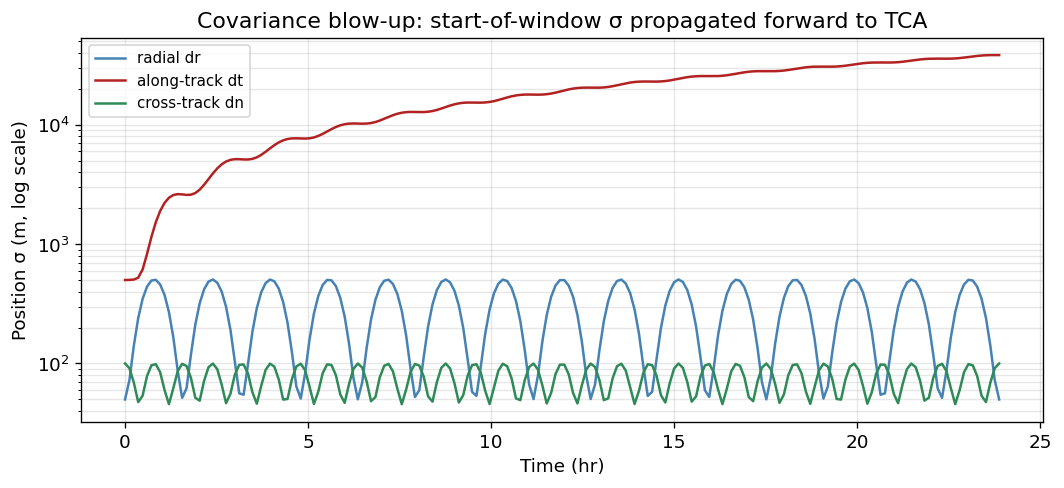

along-track σ: 500 m at t=0  ->  38270 m at TCA


In [6]:
tt = np.linspace(0.0, T, 200)
sig = np.zeros((tt.size, 3))
for i, t in enumerate(tt):
    phi = hcw_state_transition(n, t)
    cov_t = phi @ scenario.covariance @ phi.T
    sig[i] = np.sqrt(np.diag(cov_t)[:3])

fig, ax = plt.subplots(figsize=(9, 4.2))
for k, (lab, c) in enumerate([('radial dr', 'steelblue'),
                              ('along-track dt', 'firebrick'),
                              ('cross-track dn', 'seagreen')]):
    ax.semilogy(tt/3600, sig[:, k], color=c, lw=1.5, label=lab)
ax.set_xlabel('Time (hr)'); ax.set_ylabel('Position σ (m, log scale)')
ax.set_title('Covariance blow-up: start-of-window σ propagated forward to TCA')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('../figures/02_covariance_blowup.png', dpi=120)
plt.show()
print(f"along-track σ: {sig[0,1]:.0f} m at t=0  ->  {sig[-1,1]:.0f} m at TCA")

### Figure 3B — an illustrative colliding tail event (R_hbr = 10 m, realistic)

We keep the **realistic** 10 m hard-body radius and the conjunction convention
of defining the CDM covariance **at TCA** (motivated by Fig 3.0). But note the
physics: with R_hbr = 10 m and radial σ ≈ 50 m, a real conjunction has
**Pc ≈ 1e-4** — naive Monte Carlo would need ~10⁶–10⁸ samples to see a single
collision, because the 10 m sphere is a tiny target and inflating σ only spreads
the same mass thinner over it (density at the sphere falls ~1/σ²).

So Fig 3B does **not** estimate Pc by brute-force sampling. It draws **one
collision-conditioned tail sample** — a state deliberately taken from the tail
of `N(x_TCA, Σ)` that *does* pass through the sphere — purely to exercise the
`V < 0` branch on a physically meaningful (if rare) event. This is an
**illustrative sample, not a fair MC draw**.

**Step 5 plan:** the correct estimator for a Pc ≈ 1e-4 rare event is
**BRT-guided importance sampling** — sample a proposal centered on the unsafe set
`{V < 0}`, then reweight by the Gaussian likelihood ratio. That is a Step-5
deliverable, not this diagnostic.


illustrative tail sample: radial shift = 19.9 sigma_r (this is why Pc is ~1e-4 and needs importance sampling in Step 5)


tail-sample min separation = 4.00 m (< R_hbr = 10 m: True)
chosen sample min separation = 4.00 m at t = 23.876 hr


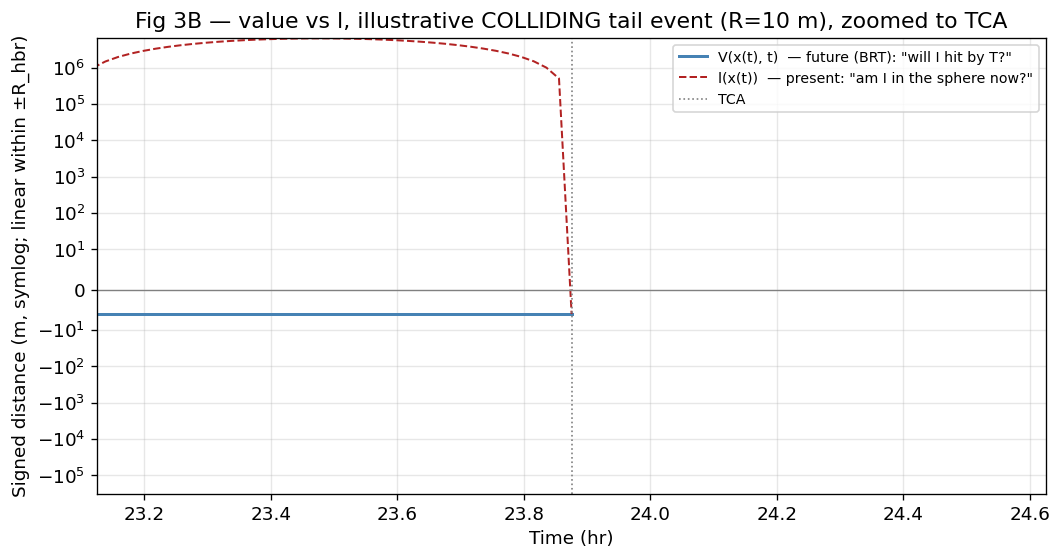

In [7]:
# CDM covariance defined AT TCA (= T); nominal state at TCA.
x_tca = hcw_state_transition(n, T) @ scenario.x0     # ~[1000, 0, 0, ...] m
phi_back = hcw_state_transition(n, -T)               # TCA -> t=0
t_eval, _ = scenario.propagate(n_steps=1200)

# Construct ONE collision-conditioned tail sample: place the position inside the
# sphere at TCA (a deep tail draw of the radial component), keep the nominal
# velocity, then back-propagate to t=0 and integrate forward. Guaranteed to
# collide -- this is an illustrative tail event, NOT a fair Monte Carlo draw.
s_tca = x_tca.copy()
s_tca[0] = 0.4 * R_hbr        # radial position pulled into the sphere (~25 sigma_r tail)
s_tca[1] = 0.0
s_tca[2] = 0.0
mahalanobis = abs(x_tca[0] - s_tca[0]) / np.sqrt(scenario.covariance[0, 0])
print(f"illustrative tail sample: radial shift = {mahalanobis:.1f} sigma_r "
      f"(this is why Pc is ~1e-4 and needs importance sampling in Step 5)")

x0 = phi_back @ s_tca
st = propagate_hcw(x0, (0.0, T), t_eval, n)
d_tca_check = separation_distance(st).min()
print(f"tail-sample min separation = {d_tca_check:.2f} m (< R_hbr = {R_hbr:.0f} m: "
      f"{d_tca_check < R_hbr})")
V_traj = value_along_trajectory(st, t_eval, T, n, R_hbr)
l_traj = signed_distance(st, hard_body_r=R_hbr)
t_tca_s, d_tca_s = time_of_closest_approach(st, t_eval)
print(f"chosen sample min separation = {d_tca_s:.2f} m at t = {t_tca_s/3600:.3f} hr")

plot_value_vs_l(t_eval, V_traj, l_traj, t_tca_s,
                'Fig 3B — value vs l, illustrative COLLIDING tail event '
                '(R=10 m), zoomed to TCA',
                '../figures/02_value_along_trajectory_sample.png')

## Next: Step 5 — Pc(t)

Figure 3B is the seed of the headline result: sweep `t` over the window and at
each `t` compute the fraction of covariance samples with `V(x, t) < 0` → the
time-evolving `Pc(t)` curve, plus the latest-safe-maneuver-time `t*`.
